# 03 · Will they make it today? (predictive model)

A product question: at a given hour, which users who have **not** reached 100 yet are likely
to fail today? Those are the ones worth a gentle evening reminder, and nobody else.

**Setup.** One row per user, day and cutoff hour (10:00, 13:00, 16:00, 19:00, 21:00) for users
still below the goal. Features use only information available *before* the cutoff (own sets,
streak, last 7 days, friends' activity). Label: reached 100 by midnight.

**Validation.** A *time-based* split: train on the first 80 days, test on the last 40. A random
split would leak the future (the same user-week in train and test) and overstate performance.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from onemore_analysis import SimConfig, simulate
from onemore_analysis.plotting import use_style, subtitle, date_axis, SERIES, REFERENCE, MUTED, INK_SECONDARY, GRID

use_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from onemore_analysis.features import complete_panel, completion_snapshots

In [2]:
cfg = SimConfig()
sim = simulate(cfg)
panel = complete_panel(sim.daily, sim.users)
snaps = completion_snapshots(sim.entries, panel, sim.edges)

FEATURES = ["cutoff_hour", "remaining", "sets_before", "hours_since_last_set",
            "streak_before", "rate_7d", "is_weekend", "friend_sets_before", "friends_done_share"]
# Domain knowledge as monotonic constraints: more reps missing can only hurt, a better
# recent record can only help. Keeps the model sane where data is sparse.
MONOTONIC = {"remaining": -1, "streak_before": 1, "rate_7d": 1}
split_day = snaps["day"].min() + np.timedelta64(80, "D")
train, test = snaps[snaps["day"] < split_day], snaps[snaps["day"] >= split_day]
X_train, y_train = train[FEATURES].astype(float), train["completed"].astype(int)
X_test, y_test = test[FEATURES].astype(float), test["completed"].astype(int)
print(f"train {len(train):,} rows · test {len(test):,} rows · positive rate {y_train.mean():.1%} / {y_test.mean():.1%}")

train 19,116 rows · test 10,026 rows · positive rate 36.1% / 26.5%


## Models

* **Baseline**: logistic regression on the obvious features only (hour, reps still missing).
* **Logistic regression** on all features (standardised).
* **Gradient boosting** (`HistGradientBoostingClassifier`), which can capture interactions
  such as "40 reps missing is easy at 13:00, hard at 21:00", with **monotonic constraints**
  on reps missing, streak and last-7-days rate.

In [3]:
models = {
    "baseline (hour + remaining)": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), ["cutoff_hour", "remaining"]),
    "logistic regression": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), FEATURES),
    "gradient boosting": (HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                                         l2_regularization=1.0, random_state=0,
                                                         monotonic_cst=[MONOTONIC.get(f, 0) for f in FEATURES]), FEATURES),
}
preds, rows = {}, []
for name, (model, cols) in models.items():
    model.fit(X_train[cols], y_train)
    p = model.predict_proba(X_test[cols])[:, 1]
    preds[name] = p
    rows.append({"model": name, "ROC AUC": roc_auc_score(y_test, p),
                 "Brier score": brier_score_loss(y_test, p), "log loss": log_loss(y_test, p)})
pd.DataFrame(rows).set_index("model")

,ROC AUC,Brier score,log loss
model,,,
baseline (hour + remaining),0.911,0.100,0.328
logistic regression,0.937,0.086,0.281
gradient boosting,0.941,0.082,0.270


Performance per cutoff hour: the later in the day, the easier the call.

In [4]:
by_hour = pd.DataFrame({
    name: test.assign(p=p).groupby("cutoff_hour").apply(lambda g: roc_auc_score(g["completed"], g["p"]), include_groups=False)
    for name, p in preds.items()
})
by_hour.index.name = "cutoff hour"
by_hour.round(3)

,baseline (hour + remaining),logistic regression,gradient boosting
cutoff hour,,,
10,0.833,0.893,0.892
13,0.890,0.925,0.921
16,0.915,0.937,0.935
19,0.950,0.957,0.960
21,0.960,0.958,0.962


## Are the probabilities trustworthy? (calibration)

For a reminder rule like "notify if P(complete) < 30%" the probabilities themselves must be
right, not just the ranking. Points on the diagonal mean "when the model says 30%, it
happens 30% of the time".

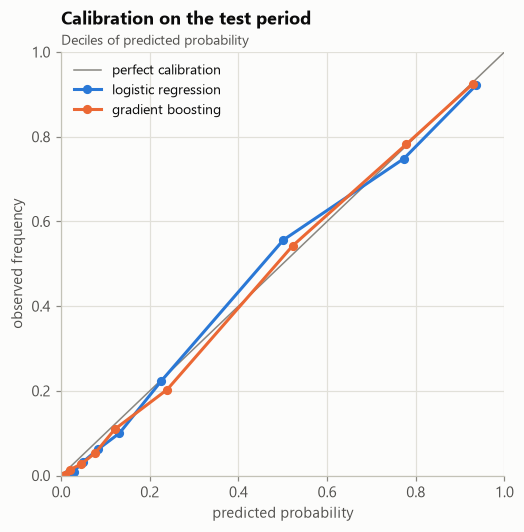

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], color=REFERENCE, linewidth=1, label="perfect calibration")
for color, name in zip(SERIES[:2], ["logistic regression", "gradient boosting"]):
    frac, mean_pred = calibration_curve(y_test, preds[name], n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, color=color, marker="o", markersize=5, label=name)
ax.set_xlabel("predicted probability")
ax.set_ylabel("observed frequency")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(axis="x")
ax.legend(loc="upper left")
ax.set_title("Calibration on the test period", pad=18)
subtitle(ax, "Deciles of predicted probability")
plt.show()

## What drives the prediction? (permutation importance on the test set)

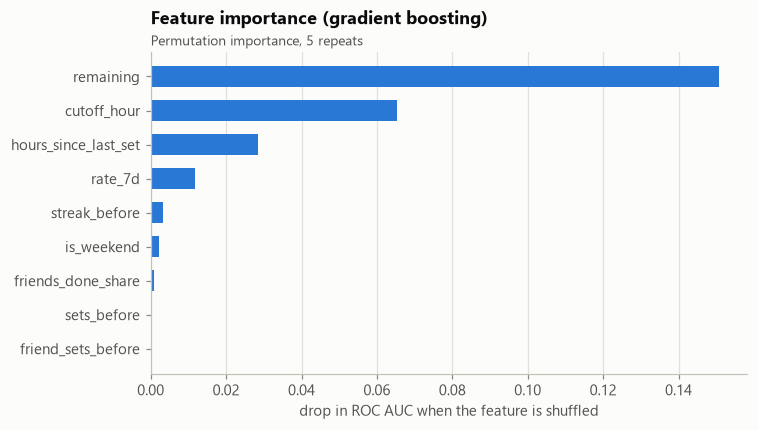

,remaining,cutoff_hour,hours_since_last_set,rate_7d,streak_before,is_weekend,friends_done_share,sets_before,friend_sets_before
AUC drop,0.151,0.065,0.029,0.012,0.003,0.002,9.559e-04,2.076e-04,2.020e-04


In [6]:
gb = models["gradient boosting"][0]
imp = permutation_importance(gb, X_test[FEATURES], y_test, scoring="roc_auc", n_repeats=5, random_state=0)
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(importance.index, importance.values, height=0.6, color=SERIES[0])
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("drop in ROC AUC when the feature is shuffled")
ax.set_title("Feature importance (gradient boosting)", pad=18)
subtitle(ax, "Permutation importance, 5 repeats")
plt.show()
importance.sort_values(ascending=False).rename("AUC drop").to_frame().T

## What the app would see at 19:00

Real rows from the test period (not hand-made profiles: invented combinations easily fall where
the model has almost no data), picked across the range of predicted probabilities, next to
what actually happened.

In [7]:
at19 = test[test["cutoff_hour"] == 19].copy()
at19["P(reaches 100)"] = gb.predict_proba(at19[FEATURES].astype(float))[:, 1]
picks = pd.concat([at19.iloc[[int((at19["P(reaches 100)"] - q).abs().argmin())]] for q in (0.05, 0.25, 0.5, 0.75, 0.95)])
picks[["remaining", "sets_before", "hours_since_last_set", "streak_before", "rate_7d", "is_weekend",
       "P(reaches 100)", "completed"]].reset_index(drop=True)

,remaining,sets_before,hours_since_last_set,streak_before,rate_7d,is_weekend,P(reaches 100),completed
0,100,0,24.000,17,1.000,False,0.050,False
1,50,2,11.491,2,0.571,False,0.248,True
2,60,2,4.659,1,0.714,False,0.498,False
3,40,2,0.150,3,0.429,False,0.749,False
4,5,4,0.188,15,1.000,False,0.951,True


## Takeaways

* Beyond the obvious (time of day and reps missing), **recent behaviour** - hours since the
  last set, the last 7 days, the current streak - adds real signal, and friends' activity a bit more.
* The models are evaluated on *future* days only, and the logistic model is close to the
  boosted one: a simple, explainable model would be enough to drive an evening reminder.
* Predictive features are **not levers**: the model says who is likely to fail, not what would
  make them succeed. Whether a reminder actually helps is a causal question, see notebook 04.
* In production the rule would be "at 19:00, remind users with P(complete) below a
  threshold", with the threshold chosen by an experiment (reminding too much has a cost).

Next: [04 · Do notifications work?](04_notification_effect.ipynb)